# SpeechLLMs using SpeechBrain

Large Language Models (LLMs) have shown impressive capabilities in language understanding and generation. A natural next step is to make those capabilities available for spoken language. Instead of only consuming text tokens, we want a model that can condition on audio and generate text. This is what SpeechLLMs are about.

The core idea is simple: we convert speech into a representation that can be consumed by an LLM by mapping it into the LLM input embedding space. Once that bridge exists, we can reuse everything that makes LLMs powerful.

In this tutorial, we'll first go through the intuition behind SpeechLLMs. Then we'll actually build one using SpeechBrain. The goal is not just to understand the architecture, but to train a working ASR system that runs on a single GPU.

## Why SpeechLLMs are different from “ASR + LM”

Using language models with speech systems is not new. Classic ASR pipelines relied on n-gram LMs (and later neural LMs) during decoding, and Transformer LMs were often used for rescoring hypotheses. However, these approaches usually keep the acoustic model and the language model as separate models combined at decoding time, which can lead to practical issues such as domain mismatch, interface complexity, multiple objectives, and engineering overhead.

A more recent and widely used approach is the cascading setup: first run an ASR system to produce a transcription, then feed that transcription into an LLM. This is currently the standard solution in many industrial and consumer applications. However, this pipeline is not jointly optimized. The ASR model is trained to minimize WER, the LLM is trained to model text, and there is no shared objective tying them together. Errors made by the ASR system are irreversibly propagated downstream to the LLM. In addition, converting speech to plain text removes paralinguistic information such as prosody, emotion, and speaker traits, which can limit the richness of downstream reasoning.

SpeechLLMs push the integration further by training a single decoder-style LLM that directly conditions on speech representations. This makes it natural to build prompted, multi-task speech-to-text systems such as ASR, speech translation, or spoken question answering, while reusing the LLM's knowledge and generation capabilities.

It is worth noting that many practical SpeechLLM systems still rely on pretrained speech encoders and LLMs, sometimes frozen. So while the architecture is conceptually end-to-end, training strategies can vary in how tightly the components are coupled.

Now that we understand the differences with the different ways the community has been exploring how to combine speech and LLMs, let's dive into the overall framework.

# Overview of the SpeechLLM framework


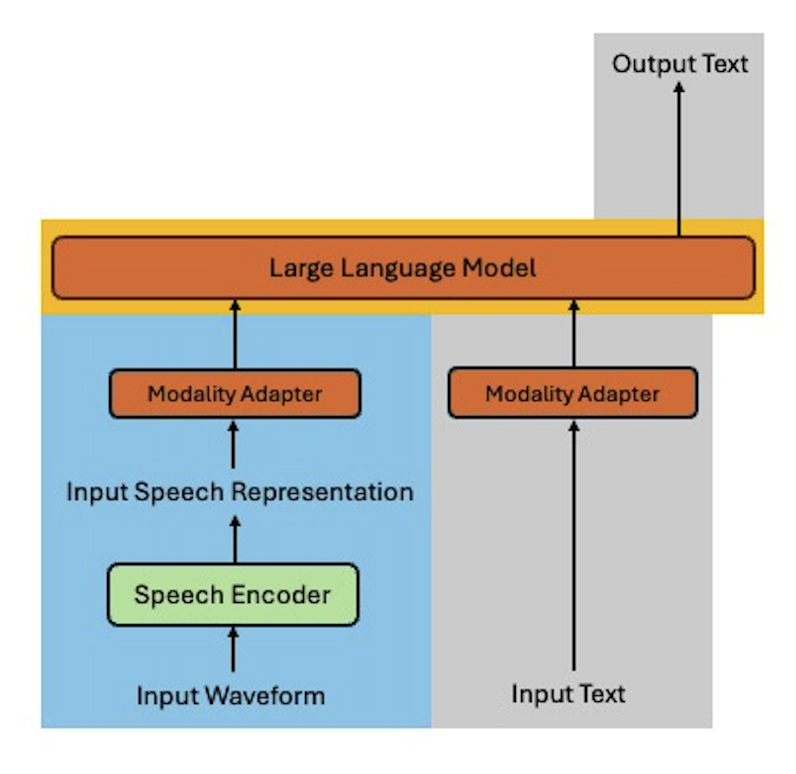

The core idea behind a SpeechLLM is simple: take a pre-trained LLM that already understands text, and teach it to also accept speech as input by projecting speech representations into the LLM input embedding space. The architecture has three main components:

1. A speech encoder that converts raw audio into a sequence of feature vectors.
2. A modality adapter that maps features into the LLM embedding space and often compresses the time dimension.
3. A pre-trained LLM decoder (e.g., a decoder-only transformer) that consumes the combined embedding sequence and generates text autoregressively. The decoder can be fully frozen or adapted (for example with LoRA).

A simplified view of the input to the LLM is:

```
<audio features> <prompt> <text tokens> [eos]
```

Here, `<audio features>` are the speech representations produced by the speech encoder and mapped by the modality adapter. These projected features are inserted directly into the LLM input embedding sequence. `<prompt>` indicates the task (e.g., “Transcribe speech to text” or “Translate speech to English”). `<text tokens>` are the target text tokens to generate, and `[eos]` marks the end of the output sequence.

Depending on the type of LLM decoder, the input sequence can differ. For instance, an instruction-following decoder may require special delimiters such as `assistant` and `user`, while a base decoder does not. It is therefore important to understand how text generation works for your chosen LLM and align the input formatting accordingly.

Training typically follows the standard causal language modeling objective: next-token prediction with cross-entropy. In practice, we compute the loss only over the target text tokens (and EOS). The audio prefix and prompt tokens provide conditioning context, but they are excluded from the loss using a label mask.

Now that we have a general idea of the main components of a SpeechLLM, let’s look at each of them in more detail.


## Speech Encoder

Text is tokenized into discrete indices (subword units or bytes), which are mapped through embedding tables and then processed by transformer layers. Speech, on the other hand, is continuous and entangles linguistic content with speaker identity, prosody, background noise, and channel effects. There is no natural tokenization of raw audio like there is for text.

The role of the speech encoder is therefore to extract meaningful representations from the waveform. This is one of the most important components of the SpeechLLM framework because it largely determines the performance ceiling of the entire system.

Typical choices include:

* Self-Supervised Learning (SSL) models such as WavLM or HuBERT
* ASR encoders such as Whisper
* Discrete speech tokenizers or codecs (e.g., Mimi-like approaches)

These encoders can produce either continuous or discrete representations depending on their design. For speech-to-text tasks like ASR, continuous representations are often a strong starting point, although discrete tokenizers are also being explored successfully in recent systems.

Each speech encoder comes with its own trade-offs: streaming capability, multilingual coverage, robustness, computational cost, and representation richness. The choice should depend on your task. For example, in large-scale speech-LLM efforts, speech encoders can reach hundreds of millions or even billions of parameters, highlighting how central this component is.

To make this concrete:

If your goal is English ASR and you do not care about streaming constraints, starting with a strong ASR encoder like Whisper or a fine-tuned SSL model is reasonable. In this case, you mainly care about capturing the linguistic content of speech.

However, if your task involves broader audio understanding, including non-speech sounds, speaker traits, or environmental cues, your encoder must preserve more than just “what was said”. It should also retain aspects like “who said it” and “in what context”.

One should not underestimate the importance of choosing the right speech encoder. No matter how powerful the LLM is, it cannot recover information that is not present in the representation. This is one reason why large research labs invest heavily in training high-quality speech encoders.

Once you have chosen your speech encoder, the next challenge is connecting its output to the LLM. Speech representations are often long sequences and live in a different latent space than the LLM embedding space. This is where the modality adapter becomes essential.



## Modality Adapter

Speech encoders and LLMs are usually designed and trained independently. As a result, their internal representation spaces rarely align naturally. Bridging that gap is the role of the modality adapter.

For instance, a speech encoder might produce representations of shape:

```
(Batch, Time, 768)
```

while the LLM expects embeddings of dimension:

```
1024
```

The mismatch is purely geometric: the feature dimensions do not align. To connect the two systems, we introduce a small trainable projector that maps:

```
(Batch, Time, speech_dim) → (Batch, Time, llm_dim)
```

In practice, a simple MLP is often sufficient:

```python
import torch.nn as nn

speech_encoder_out_dim = 768
intermediate_dim = 2048
llm_input_dim = 1024

linear_projector = nn.Sequential(
    nn.Linear(speech_encoder_out_dim, intermediate_dim, bias=False),
    nn.GELU(),
    nn.Linear(intermediate_dim, llm_input_dim, bias=False),
)
```

This projector is trained jointly with the language modeling objective. Rather than solving a standalone regression task, it gradually learns to reshape speech features into a region of the embedding space that the LLM can effectively interpret.

The literature proposes many alternatives: attention-based resamplers, Q-Former-style modules, CTC-inspired compression schemes, and more. Yet in many practical setups, simple linear projectors remain surprisingly competitive. Often, the straightforward solution is already strong enough to serve as a solid baseline.


### The time dimension problem

Dimensional alignment is only part of the story. The time axis introduces a second challenge.

If a speech encoder operates at 50 Hz, it produces 50 embeddings per second. Humans, however, typically speak only a few words per second. This creates a significant density mismatch between speech frames and text tokens. The model must implicitly learn how to align these two scales.

There is also the constraint imposed by the LLM context window. With a 2048-token window, feeding raw 50 Hz features allows at most:

```
2048 / 50 ≈ 41 seconds
```

of audio, and that is before accounting for prompts and generated text. For longer recordings, this quickly becomes restrictive.


### Compressing the time dimension

One simple way to address this issue is to concatenate groups of `k` consecutive frames along the feature dimension. Conceptually:

Input:

```
(Batch, Time, F)
```

Output:

```
(Batch, Time/k, F*k)
```

This requires:

```
Time % k == 0
```

If the sequence length is not divisible by `k`, the remaining frames can simply be trimmed.

A minimal implementation looks like this:

```python
class ConcatDownsampler(nn.Module):
    def __init__(self, downsampling_factor):
        super().__init__()
        self.k = downsampling_factor

    def forward(self, x):
        batch_size, seq_len, dim = x.size()
        remainder = seq_len % self.k
        if remainder > 0:
            x = x[:, :-remainder, :]
        seq_len = x.size(1)
        return x.view(batch_size, seq_len // self.k, dim * self.k)

downsampler = ConcatDownsampler(downsampling_factor=5)
```

By reducing the time resolution, we make longer audio segments fit inside the LLM context window while preserving local structure within each group of frames.

The choice of `downsampling_factor` reflects a trade-off. Larger values shrink the sequence more aggressively but may blur fine-grained temporal information. In many practical systems, reducing the frame rate to roughly 10–15 Hz provides a reasonable balance, although the optimal value ultimately depends on the task and the speech encoder.

### Putting the pieces together

Before passing representations to the LLM, the pipeline typically looks like this:

```python
x = ...  # waveform of shape (B, T)

speech_feats = speech_encoder(x)      # (B, T', F)
downsampled = downsampler(speech_feats)  # (B, T'/k, F*k)
projected = linear_projector(downsampled)  # (B, T'/k, LLM_feat_dim)
```

The projected embeddings are then inserted directly into the LLM input sequence.

While the design space for modality adapters is broad and still evolving, starting with time compression followed by a linear projection offers a clean and effective baseline. From there, more sophisticated alternatives can be explored if needed.

With the encoder and adapter in place, we can now turn to the decoder and training strategy.




## Large Language Model and Training

Large Language Models are typically causal decoder-only transformers trained to predict the next token `w_i`:

```
p(w_i | w_<i)
```

In the SpeechLLM setting, this objective is extended so that the model conditions not only on previous tokens but also on speech embeddings:

```
p(w_i | w_<i, s)
```

where `s` represents the full sequence of projected speech representations. This simple modification is what turns a text-only decoder into a speech-aware model.

The LLM can be either a base model or an instruction-tuned one. In practice, instruction-tuned models are often easier to use in multi-task settings because they already expect structured prompts. What matters most is that the prompt formatting matches the model's training regime.


### Model size and compute constraints

LLMs can range from relatively small models to extremely large ones. Scaling laws have shown a clear relationship between model size, data, and compute: larger models trained with more data tend to achieve lower language modeling loss. This is one of the main reasons why LLMs continue to grow.

However, scaling comes at a cost. Larger models require significantly more memory and compute. Once speech is introduced into the pipeline, the situation becomes even more demanding: speech encoders can themselves be large, and speech sequences are much longer than text sequences. The quadratic attention cost becomes particularly relevant when handling long audio segments.

In practice, hardware constraints often dictate architectural choices.

### Adapting large decoders efficiently

One popular strategy for adapting large LLMs without updating all parameters is LoRA (Low-Rank Adaptation). Instead of replacing linear layers, LoRA injects small trainable low-rank matrices into selected layers, typically attention projections. This allows the model to adapt while keeping the vast majority of parameters frozen.

This means fewer trainable parameters, lower memory usage, and more accessible fine-tuning. LoRA can also be combined with low-precision loading (for example 4-bit weights), which further reduces memory requirements.


### Do we need to fine-tune the decoder?

Interestingly, recent work has shown that for speech tasks (e.g., ASR), it is not always necessary to fine-tune the decoder at all. In modality adapter-only setups (often referred to as SLAM-style approaches), both the speech encoder and the LLM remain frozen, and only the modality adapter is trained.

At first glance, this may seem surprising. However, one possible explanation is that the projector learns to reshape speech representations into a region of the embedding space where the frozen LLM can effectively decode them into text. In other words, the burden of adaptation is concentrated in the projection layer.

While full or LoRA-based adaptation of the decoder often leads to stronger results, projector-only training offers a very strong and efficient baseline, especially when compute is limited.

### Freezing strategies

Once the speech encoder and modality adapter are defined, several training strategies become possible:

1. **Projector-only training**
   Freeze both speech encoder and decoder. Train only the projector.

2. **Encoder + projector fine-tuning**
   Freeze the decoder. Fine-tune the speech encoder together with the projector.

3. **Decoder adaptation (e.g. LoRA)**
   Keep encoder and projector fixed, and adapt the decoder.

These stages can also be combined sequentially. For example, one might start with projector-only training and then progressively unfreeze additional components.

The right strategy depends on compute budget and target performance.

## Recap

We have now covered the three main components of a SpeechLLM:

* A speech encoder that extracts representations from raw audio
* A modality adapter that compresses and maps those representations into the LLM embedding space
* A decoder-only LLM trained with next-token prediction conditioned on speech

Even without updating the decoder weights, a well-designed encoder and projector can already produce strong ASR systems. From there, additional adaptation strategies such as LoRA can further improve performance when resources allow.

One practical advantage of using SpeechBrain is that these variations are easy to explore. Freezing the speech encoder can be done with a simple flag, and adapting a pretrained LLM with LoRA can be achieved through the provided adapter utilities.


# Practical ASR example with SpeechBrain

Now that we've covered the theory behind SpeechLLMs, it's time to move to the fun part: actually building one. In this section, we will combine the concepts we've discussed with SpeechBrain and train a working SpeechLLM for ASR.

As mentioned earlier, there are multiple ways to train such a system. To keep things simple and affordable, we will start with the SLAM-style setup, where both the speech encoder and the decoder are frozen and only the modality adapter is trained. Throughout the Colab, we will also indicate what needs to change if you want to move toward multi-stage or fully end-to-end training.

We will proceed in two steps. First, we extract offline speech representations from a pre-trained encoder. This allows us to save GPU memory during training and dedicate most of it to the LLM. Then, we load these cached features and integrate them into our SpeechLLM training pipeline.

By the end of this section, you will have a fully working ASR SpeechLLM running on a single GPU!

### Installing SpeechBrain

First, let's install SpeechBrain on your machine! We are using the `develop` branch to stay up-to-date with new commits.

In [1]:
%%capture
# Installing SpeechBrain via pip
BRANCH = 'develop'
!python -m pip install git+https://github.com/speechbrain/speechbrain.git@$BRANCH

In [1]:
import speechbrain
import torch

In this tutorial we will use LibriSpeech, a famous ASR corpus. We will use the official training and development sets.

In [2]:
%%capture
# downloading mini_librispeech dev data
!wget https://www.openslr.org/resources/31/dev-clean-2.tar.gz
!tar -xvzf dev-clean-2.tar.gz

!wget https://openslr.trmal.net/resources/12/train-clean-100.tar.gz
!tar -xvzf train-clean-100.tar.gz

First we must set up the data pipeline for downloaded MiniLibriSpeech data.

If you are not familiar with **SpeechBrain dataIO** you may want to take a look at the [tutorial](https://speechbrain.readthedocs.io/en/latest/tutorials/basics/data-loading-pipeline.html).

In [3]:
%%capture
!pip install pandas
!pip install h5py
!pip install transformers

In [5]:
import glob
from pathlib import Path
import json
import pandas as pd
import os

def parse_to_json(dev_clean_root):
  """ Helper function to parse the LibriSpeech dataset into a json manifest.
  """
  flac_files = glob.glob(os.path.join(dev_clean_root, "**/*.flac"),
                          recursive=True)

  # in this dataset files names are spk_id-chapter_id-utterance_id.flac
  text_files = glob.glob(os.path.join(dev_clean_root, "**/*.txt"),
                          recursive=True)
  # we build a dictionary with words for each utterance
  words_dict = {}
  for txtf in text_files:
      with open(txtf, "r") as f:
          lines = f.readlines()
      for l in lines:
          l = l.strip("\n")
          utt_id = l.split(" ")[0]
          words = " ".join(l.split(" ")[1:])
          words_dict[utt_id] = words
  # we now build JSON examples
  examples = {}
  for utterance in flac_files:
      utt_id = Path(utterance).stem
      examples[utt_id] = {"wav": utterance,
                          "words": words_dict[utt_id],
                          "spkID": "speaker_" + utt_id.split("-")[0],
                          "duration": speechbrain.dataio.dataio.read_audio_info(utterance).num_frames}

  with open("data.json", "w") as f:
      json.dump(examples, f, indent=4)


parse_to_json("/users/amoumen/jean-zay-home/proj/speechbrain/LibriSpeech/dev-clean-2")

OSError: [Errno 5] Input/output error

In [9]:
from speechbrain.dataio.dataset import DynamicItemDataset
dataset = DynamicItemDataset.from_json("data.json")

To make the training faster, we limit only up to the first one hundred samples from the training dataset!

In [10]:
dataset = dataset.filtered_sorted(sort_key="duration", select_n=100)

## Feature Caching: Precomputing SSL Features on Disk

When the speech encoder (e.g., WavLM) is **frozen**, the SSL features it produces for a given utterance are always the same. Recomputing them at every epoch is wasteful: it burns GPU cycles and slows down training, especially with large SSL models.

A better approach is to **extract the features once and cache them on disk**. During training, the cached features are loaded directly — skipping the SSL forward pass entirely. This brings two major benefits:

1. **Faster training**: loading pre-computed features from disk is much cheaper than running a large SSL encoder on raw audio at every iteration.
2. **Lower GPU memory**: the SSL encoder no longer needs to be loaded into GPU memory during training, freeing up VRAM for larger batch sizes or bigger LLMs.

The tradeoff is straightforward: disk space for speed and memory. With gzip compression, the storage cost is manageable.

SpeechBrain provides `CachedHDF5DynamicItem` to make this seamless. It plugs directly into the SpeechBrain data pipeline: the first time a feature is requested, it is computed and saved to an HDF5 file; on subsequent accesses, it is loaded from the cache. All features for a dataset are stored in a single HDF5 file, which is efficient for sequential reads.

Let's see how this works in practice with our dataset.

### Step 1: Define the audio pipeline and the cached feature computation

We first define the standard audio loading pipeline, then wrap the SSL feature extraction with the `@CachedHDF5DynamicItem.cache` decorator. This decorator intercepts every call: if the feature for a given utterance ID is already in the HDF5 file, it loads it; otherwise, it computes the feature, stores it, and returns it.

In this notebook, we will use Whisper Encoder large-v3, as it demonstrates strong ASR and multilingual performances. So we first import it, and then we run hidden state extraction for each `id` in our dataset.

In [ ]:
import speechbrain as sb
from speechbrain.integrations.hdf5.cached_item import CachedHDF5DynamicItem
import torch

# Where to store the cached features
feats_cache_dir = "./feats_cache"

# --- 1. Audio loading pipeline (reads raw waveform from disk) ---
@sb.utils.data_pipeline.takes("wav")
@sb.utils.data_pipeline.provides("sig")
def audio_pipeline(wav):
    """Load raw audio waveform from file."""
    return sb.dataio.dataio.read_audio(wav)

# --- 2. SSL feature extraction with caching ---
# Load a frozen speech encoder (can be WavLM, HuBERT, Whisper, etc.)
from speechbrain.lobes.models.huggingface_transformers.whisper import Whisper

device = "cuda" if torch.cuda.is_available() else "cpu"
speech_encoder = Whisper(
    source="openai/whisper-large-v3",
    save_path="./savedir/whisper-large-v3",
    freeze=True,
    encoder_only=True,
    sampling_rate=16000,
).to(device).eval()

# The @CachedHDF5DynamicItem.cache decorator wraps a DynamicItem so that:
#   - On first call for an utterance: computes the feature, saves to HDF5, returns it.
#   - On subsequent calls: loads directly from HDF5 (skipping SSL forward pass).
@CachedHDF5DynamicItem.cache(feats_cache_dir, compression="gzip")
@sb.utils.data_pipeline.takes("id", "sig")
@sb.utils.data_pipeline.provides("feats")
def compute_feats(uid, sig):
    """Extract speech encoder features from audio and cache them."""
    sig = sig.to(device).unsqueeze(0)  # (T,) -> (1, T)
    length = torch.ones(1, device=device)
    with torch.no_grad(), torch.autocast(device_type=device):
        feats = speech_encoder(sig, length)
    return feats.squeeze(0).cpu()  # (T', D) back to CPU for storage

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

### Step 2: Register the pipelines with the dataset and warm the cache

We attach both pipelines (`audio_pipeline` and `compute_feats`) to the dataset as dynamic items. Then we call `iterate_once` to walk through every utterance — this triggers the SSL forward pass for each sample and populates the HDF5 cache. This step only needs to happen once; after that, the cache file on disk has all the features.

In [17]:
# Register the dynamic items and set the output keys
dataset.add_dynamic_item(audio_pipeline)
dataset.add_dynamic_item(compute_feats)
dataset.set_output_keys(["id", "sig", "feats"])

# Warm the cache: iterate once through the dataset.
# This computes SSL features for every utterance and stores them in the HDF5 file.
# On a GPU, this is fast; on CPU it will be slower but only needs to happen once.
print("Warming the feature cache...")
dataset.iterate_once(output_keys=["feats"])
print("Cache warming complete!")

Warming the feature cache...


100%|██████████| 100/100 [00:44<00:00,  2.26it/s]

Cache warming complete!


### Step 3: Verify the cache

We can inspect the HDF5 file to confirm that features have been cached. Each utterance ID is a key in the file, mapping to its feature tensor.

In [18]:
import h5py
import os

cache_path = os.path.join(feats_cache_dir, "cache.hdf5")
with h5py.File(cache_path, "r") as f:
    keys = list(f.keys())
    print(f"Number of cached utterances: {len(keys)}")
    # Inspect the first cached entry
    first_key = keys[0]
    feats = f[first_key][:]
    print(f"Utterance '{first_key}': feature shape = {feats.shape}  (frames, feature_dim)")

Number of cached utterances: 100
Utterance '3752-4944-0000': feature shape = (1500, 1280)  (frames, feature_dim)


### Step 4: Load cached features at training time (without the SSL encoder)

Once the cache is built, you no longer need the SSL encoder in memory. At training time, you create a `CachedHDF5DynamicItem` in **read-only mode** (`file_mode="r"`) that loads features directly from the HDF5 file. The SSL model can be discarded entirely.

In [20]:
del speech_encoder
torch.cuda.empty_cache()

In [21]:
# At training time: load features from cache (no SSL model needed!)
feats_loader = CachedHDF5DynamicItem(
    feats_cache_dir,
    file_mode="r",           # read-only: safe for multi-process DataLoader
    takes=["id"],
    provides=["feats"],
    compression="gzip",
)

# Build a fresh dataset that uses cached features instead of raw audio
train_dataset = DynamicItemDataset.from_json("data.json")
train_dataset = train_dataset.filtered_sorted(sort_key="duration", select_n=100)
train_dataset.add_dynamic_item(feats_loader)
train_dataset.set_output_keys(["id", "feats"])

# Verify: accessing feats now reads from HDF5, not from the SSL model
sample = train_dataset[0]
print(f"Loaded cached features for '{sample['id']}': shape = {sample['feats'].shape}")

Loaded cached features for '8842-304647-0007': shape = (1500, 1280)


Notice that the SSL model is no longer involved. The `feats_loader` reads directly from `feats_cache/cache.hdf5` using only the utterance ID as a key. This is the pattern used in the SpeechBrain `LibriSpeech` SpeechLLM recipe: the `extract_ssl_feats.py` script warms the cache once, and then `train_speechllm.py` with the `speechllm_ssl_feats.yaml` config loads features in read-only mode during training.

The great thing about this caching feature is that it is also compatible with extracting text tokens as well! You can directly save on disk the indices without havint to recompute them on the fly.

# Automatic Speech Recognition with our SpeechLLM

Now that we have cached speech features on disk, we can build the full SpeechLLM ASR training pipeline.

In this section, we mirror the structure of the SpeechBrain LibriSpeech recipe (`train_speechllm.py` + `speechllm_ssl_feats.yaml`):

1. Load a pretrained LLM in SpeechBrain
2. Define prompt-aware token formatting for ASR
3. Enable optional LoRA adaptation
4. Train with cached speech features and text-only loss masking


## Step 1: Configuration and imports

We start with a minimal, recipe-aligned setup: cached features as input, prompt-conditioned text targets, and optional LoRA on top of a pretrained LLM.


In [ ]:
import json
from pathlib import Path

import torch
import speechbrain as sb

from speechbrain.dataio.dataset import DynamicItemDataset
from speechbrain.integrations.hdf5.cached_item import CachedHDF5DynamicItem
from speechbrain.integrations.huggingface.llama import LLaMA
from speechbrain.lobes.downsampling import ConcatDownsampler
from speechbrain.lobes.models.VanillaNN import VanillaNN
from speechbrain.nnet.adapters import AdaptedModel, LoRA
from speechbrain.decoders.seq2seq import S2SHuggingFaceLLMGreedySearcher

device = "cuda" if torch.cuda.is_available() else "cpu"
ignore_index = -100
downsampling_factor = 4
prompt = "Transcribe speech to text."

# Use a small public LLaMA-compatible checkpoint for tutorial/demo purposes.
# Replace with your target checkpoint in real experiments.
llm_source = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
llm_save_path = "./pretrained_models/tinyllama"
use_lora = True
lora_rank = 16

llm_dtype = torch.bfloat16 if device == "cuda" else torch.float32


## Step 2: Load the LLM with SpeechBrain and choose LoRA or not

Like in the SpeechBrain recipe, we add `<|start_of_audio|>` and `<|end_of_audio|>` as extra special tokens, then optionally wrap the LLM with `AdaptedModel + LoRA`.


In [ ]:
backbone_llm = LLaMA(
    source=llm_source,
    save_path=llm_save_path,
    freeze=True,
    torch_dtype=llm_dtype,
    additional_special_tokens=["<|start_of_audio|>", "<|end_of_audio|>"],
)
backbone_llm = backbone_llm.to(device)

tokenizer = backbone_llm.tokenizer
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

bos_index = tokenizer.bos_token_id
if bos_index is None:
    bos_index = tokenizer.eos_token_id
eos_index = tokenizer.eos_token_id
pad_index = tokenizer.pad_token_id

start_of_audio_index = tokenizer.convert_tokens_to_ids("<|start_of_audio|>")
end_of_audio_index = tokenizer.convert_tokens_to_ids("<|end_of_audio|>")

if use_lora:
    llm = AdaptedModel(
        model_to_adapt=backbone_llm,
        adapter_class=LoRA,
        all_linear=True,
        adapter_kwargs={"rank": lora_rank},
    )
else:
    llm = backbone_llm

llm = llm.to(device)
print(f"Device: {device} | use_lora={use_lora} | bos={bos_index} eos={eos_index} pad={pad_index}")


## Step 3: Build the prompt-aware data pipeline on top of cached features

We keep the same idea as `train_speechllm.py`:

- Load `feats` from `CachedHDF5DynamicItem` (read-only mode)
- Build `tokens_bos` with `[start_audio, end_audio, prompt, bos, text]`
- Build `tokens_eos` with `[text, eos]`


In [ ]:
# Optional: deterministic train/valid split from data.json
full_json = Path("data.json")
with full_json.open(encoding="utf-8") as f:
    data_dict = json.load(f)

all_ids = sorted(list(data_dict.keys()))
split_idx = max(1, int(0.9 * len(all_ids)))
train_ids = all_ids[:split_idx]
valid_ids = all_ids[split_idx:]
if len(valid_ids) == 0:
    valid_ids = train_ids[-1:]

train_dict = {k: data_dict[k] for k in train_ids}
valid_dict = {k: data_dict[k] for k in valid_ids}

train_json = Path("train_data.json")
valid_json = Path("valid_data.json")
train_json.write_text(json.dumps(train_dict, indent=2), encoding="utf-8")
valid_json.write_text(json.dumps(valid_dict, indent=2), encoding="utf-8")

prompt_ids = tokenizer(prompt, add_special_tokens=False).input_ids

@sb.utils.data_pipeline.takes("wrd")
@sb.utils.data_pipeline.provides(
    "wrd", "tokens_list", "tokens_bos", "tokens_eos", "tokens", "prompt_len"
)
def text_pipeline(wrd):
    yield wrd

    tokens_list = tokenizer(wrd, add_special_tokens=False).input_ids
    yield tokens_list

    tokens_bos = torch.LongTensor(
        [start_of_audio_index]
        + [end_of_audio_index]
        + prompt_ids
        + [bos_index]
        + tokens_list
    )
    yield tokens_bos

    tokens_eos = torch.LongTensor(tokens_list + [eos_index])
    yield tokens_eos

    yield torch.LongTensor(tokens_list)

    prompt_len = len([start_of_audio_index] + [end_of_audio_index] + prompt_ids)
    yield prompt_len

feats_loader = CachedHDF5DynamicItem(
    feats_cache_dir,
    file_mode="r",
    takes=["id"],
    provides=["feats"],
    compression="gzip",
)

def build_dataset(json_path):
    ds = DynamicItemDataset.from_json(str(json_path))
    ds.add_dynamic_item(text_pipeline)
    ds.add_dynamic_item(feats_loader)
    ds.set_output_keys([
        "id",
        "wrd",
        "tokens_bos",
        "tokens_eos",
        "tokens",
        "prompt_len",
        "feats",
    ])
    return ds

train_data = build_dataset(train_json)
valid_data = build_dataset(valid_json)
print(f"Train size: {len(train_data)} | Valid size: {len(valid_data)}")


## Step 4: Define projector, downsampler, and decoding searcher

This matches the recipe design: downsample speech frames, project to the LLM embedding size, then decode with `S2SHuggingFaceLLMGreedySearcher`.


In [ ]:
example = train_data[0]
speech_feat_dim = int(example["feats"].shape[-1])
llm_emb_size = int(llm.model.get_input_embeddings().weight.shape[-1])

feat_downsampler = ConcatDownsampler(downsampling_factor=downsampling_factor)
proj = VanillaNN(
    input_shape=[None, None, speech_feat_dim * downsampling_factor],
    dnn_blocks=2,
    dnn_neurons=llm_emb_size,
    activation=sb.nnet.activations.ReLU,
)

searcher = S2SHuggingFaceLLMGreedySearcher(
    llm_model=llm,
    temperature=0.0,
    min_decode_ratio=0.0,
    max_decode_ratio=1.0,
    bos_index=bos_index,
    eos_index=eos_index,
)

modules = {
    "feat_downsampler": feat_downsampler,
    "proj": proj,
    "llm": llm,
    "searcher": searcher,
}

for m in modules.values():
    m.to(device)

collate_fn = lambda batch: sb.dataio.batch.PaddedBatch(
    batch,
    per_key_padding_kwargs={
        "tokens_bos": {"value": pad_index},
        "tokens_eos": {"value": ignore_index},
    },
)

train_dataloader_opts = {
    "batch_size": 2,
    "shuffle": True,
    "num_workers": 0,
    "collate_fn": collate_fn,
}

valid_dataloader_opts = {
    "batch_size": 1,
    "shuffle": False,
    "num_workers": 0,
    "collate_fn": collate_fn,
}


## Step 5: Implement the SpeechLLM ASR `Brain`

The forward path is:

- `cached feats -> downsampler -> projector`
- concatenate with text embeddings in multimodal order
- run LLM and compute CE only on text targets (`ignore_index` for speech prefix positions)


In [ ]:
import torch.nn.functional as F

def get_multimodal_attention_mask(wav, wav_lens, txt, txt_lens, device):
    batch_size = wav.size(0)
    wav_len = wav.size(1)
    txt_len = txt.size(1)
    total_len = wav_len + txt_len

    attention_mask = torch.zeros(batch_size, total_len, dtype=torch.bool, device=device)
    for i in range(batch_size):
        actual_wav_len = int(torch.round(wav_lens[i] * wav_len).item())
        actual_txt_len = int(torch.round(txt_lens[i] * txt_len).item())

        attention_mask[i, 0] = True
        attention_mask[i, 1 : 1 + actual_wav_len] = True

        remaining_txt = max(actual_txt_len - 1, 0)
        attention_mask[i, 1 + wav_len : 1 + wav_len + remaining_txt] = True

    return attention_mask


class SpeechLLMASRBrain(sb.Brain):
    def __init__(self, *args, tokenizer=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.tokenizer = tokenizer
        self.txt_embedding = self.modules.llm.model.get_input_embeddings()

    def compute_forward(self, batch, stage):
        batch = batch.to(self.device)

        tokens_bos, tokens_bos_lens = batch.tokens_bos
        feats, feats_lens = batch.feats

        audio_down_feats = self.modules.feat_downsampler(feats)
        projected_audio_feats = self.modules.proj(audio_down_feats)

        txt_embds = self.txt_embedding(tokens_bos)
        multimodal_embds = torch.cat(
            [
                txt_embds[:, 0].unsqueeze(1),
                projected_audio_feats,
                txt_embds[:, 1:],
            ],
            dim=1,
        )

        attention_mask = get_multimodal_attention_mask(
            projected_audio_feats,
            feats_lens,
            txt_embds,
            tokens_bos_lens,
            self.device,
        )

        logits = self.modules.llm(
            inputs_embeds=multimodal_embds,
            attention_mask=attention_mask,
        ).logits

        hyps = None
        if stage != sb.Stage.TRAIN:
            prompt_len = batch.prompt_len
            if isinstance(prompt_len, tuple):
                prompt_len = prompt_len[0]

            audio_and_prompt_len = projected_audio_feats.shape[1] + int(prompt_len[0].item())
            hyps = self.modules.searcher(
                multimodal_embds[:, :audio_and_prompt_len],
                feats_lens,
                attention_mask[:, :audio_and_prompt_len],
            )

        return logits, hyps

    def compute_objectives(self, predictions, batch, stage):
        logits, _ = predictions
        tokens_eos, _ = batch.tokens_eos

        num_audio_feats = logits.shape[1] - tokens_eos.shape[1]
        target_tokens = torch.cat(
            [
                torch.full(
                    (tokens_eos.shape[0], num_audio_feats),
                    self.hparams.ignore_index,
                    device=self.device,
                ),
                tokens_eos,
            ],
            dim=1,
        ).long()

        loss = F.cross_entropy(
            logits.view(-1, logits.shape[-1]),
            target_tokens.view(-1),
            ignore_index=self.hparams.ignore_index,
        )
        return loss

    def init_optimizers(self):
        trainable_params = [p for p in self.modules.parameters() if p.requires_grad]
        self.optimizer = self.hparams.opt(trainable_params)
        if self.checkpointer is not None:
            self.checkpointer.add_recoverable("optimizer", self.optimizer)


## Step 6: Train (or dry-run)

We keep a guard variable so the notebook is safe to run by default. Set `RUN_TRAINING=True` when you are ready.


In [ ]:
hparams = {
    "ignore_index": ignore_index,
    "opt": lambda params: torch.optim.AdamW(params, lr=5e-4, weight_decay=0.0),
    "epoch_counter": sb.utils.epoch_loop.EpochCounter(limit=1),
}

asr_brain = SpeechLLMASRBrain(
    modules=modules,
    hparams=hparams,
    run_opts={"device": device},
    tokenizer=tokenizer,
)

RUN_TRAINING = False

if RUN_TRAINING:
    asr_brain.fit(
        asr_brain.hparams.epoch_counter,
        train_data,
        valid_data,
        train_loader_kwargs=train_dataloader_opts,
        valid_loader_kwargs=valid_dataloader_opts,
    )
else:
    print("Set RUN_TRAINING=True to launch SpeechLLM ASR fine-tuning.")


### Notes

- **Projector-only setup**: set `use_lora=False` and keep `backbone_llm.freeze=True`
- **LoRA setup**: set `use_lora=True` (as above)
- **End-to-end variant**: switch from cached `feats` to on-the-fly speech encoder outputs (as in `speechllm_e2e.yaml`)

This is the exact conceptual flow of SpeechBrain's SpeechLLM ASR recipe, adapted to this notebook format.


## Citing SpeechBrain

If you use SpeechBrain in your research or business, please cite it using the following BibTeX entry:

```bibtex
@misc{speechbrainV1,
  title={Open-Source Conversational AI with {SpeechBrain} 1.0},
  author={Mirco Ravanelli and Titouan Parcollet and Adel Moumen and Sylvain de Langen and Cem Subakan and Peter Plantinga and Yingzhi Wang and Pooneh Mousavi and Luca Della Libera and Artem Ploujnikov and Francesco Paissan and Davide Borra and Salah Zaiem and Zeyu Zhao and Shucong Zhang and Georgios Karakasidis and Sung-Lin Yeh and Pierre Champion and Aku Rouhe and Rudolf Braun and Florian Mai and Juan Zuluaga-Gomez and Seyed Mahed Mousavi and Andreas Nautsch and Xuechen Liu and Sangeet Sagar and Jarod Duret and Salima Mdhaffar and Gaelle Laperriere and Mickael Rouvier and Renato De Mori and Yannick Esteve},
  year={2024},
  eprint={2407.00463},
  archivePrefix={arXiv},
  primaryClass={cs.LG},
  url={https://arxiv.org/abs/2407.00463},
}